# Proyecto de Aprendizaje No Supervisado: Olivetti Faces
##### Realizado por: *Coutiño Morales Francisco José*
***

## 1. Introducción y Preparación de Datos

En este proyecto exploraremos técnicas de agrupamiento (Clustering) y modelado de densidad (GMM) aplicadas a imágenes faciales. Trabajaremos con el dataset **Olivetti Faces**, que contiene 400 imágenes de 64x64 píxeles correspondientes a 40 personas distintas (10 fotos por persona).

### Objetivo de la Fase 1
El primer desafío es utilizar el algoritmo **K-Means** para agrupar estas imágenes. A diferencia de la clasificación clásica, aquí no le diremos al modelo "esta foto es de Juan"; el modelo debe descubrir por sí solo qué fotos se parecen entre sí basándose en la estructura de los píxeles.

### Carga del Dataset
Primero, cargamos los datos y verificamos su estructura. Cada imagen ha sido aplanada (*flattened*) a un vector de 4,096 dimensiones ($64 \times 64 = 4096$).

Cargando Olivetti Faces...
downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\Francisco\scikit_learn_data
Dimensiones del Dataset: (400, 4096)
Rango de valores de píxeles: Min=0.0, Max=1.0
Ejemplo de las primeras 5 imágenes:


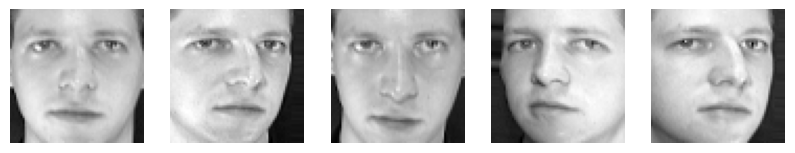

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# 1. Cargar el dataset
print("Cargando Olivetti Faces...")
olivetti = fetch_olivetti_faces()

# X = Datos (Imágenes aplanadas), y = Etiquetas (ID de la persona, solo para validar)
X = olivetti.data
y = olivetti.target

print(f"Dimensiones del Dataset: {X.shape}")
print(f"Rango de valores de píxeles: Min={X.min()}, Max={X.max()}")

# Función auxiliar para visualizar caras (nos servirá todo el proyecto)
def plot_faces(faces, n_cols=5):
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2, n_rows * 2.2))
    for index, face in enumerate(faces):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face.reshape(64, 64), cmap="gray")
        plt.axis("off")
    plt.show()

# Visualizamos las primeras 5 caras para entender los datos
print("Ejemplo de las primeras 5 imágenes:")
plot_faces(X[:5])

## 2. División Estratificada de Datos

La tarea nos advierte que el dataset es pequeño (solo 400 imágenes). Si hiciéramos una división aleatoria simple (`train_test_split` estándar), correríamos el riesgo de que **alguna de las 40 personas quede totalmente fuera del set de entrenamiento**.

Si el modelo nunca ve a la "Persona X" durante el entrenamiento, será imposible que aprenda a agruparla correctamente o detectarla como anomalía después.

**Mi Estrategia:**
Utilizaré `StratifiedShuffleSplit`. Esto garantiza matemáticamente que la proporción de fotos por persona se mantenga idéntica en los conjuntos de Entrenamiento, Validación y Prueba.
* **Train:** Para que el algoritmo aprenda.
* **Validation:** Para ajustar hiperparámetros (como el número de clústeres $k$).
* **Test:** Para la evaluación final.

In [2]:
from sklearn.model_selection import StratifiedShuffleSplit

# Usamos StratifiedShuffleSplit para garantizar que haya fotos de TODAS las personas en cada set
# Paso 1: Separar Test (20%) del resto (80%)
split_1 = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=42) # 40 imágenes = 1 por persona para test
for train_valid_idx, test_idx in split_1.split(X, y):
    X_train_valid, X_test = X[train_valid_idx], X[test_idx]
    y_train_valid, y_test = y[train_valid_idx], y[test_idx]

# Paso 2: Separar Validation (20% aprox del total original) del Train
split_2 = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=43) # Otras 40 para validación
for train_idx, valid_idx in split_2.split(X_train_valid, y_train_valid):
    X_train, X_valid = X_train_valid[train_idx], X_train_valid[valid_idx]
    y_train, y_valid = y_train_valid[train_idx], y_train_valid[valid_idx]

print(f"Set de Entrenamiento: {X_train.shape} (Debe tener 320 imágenes, 8 por persona)")
print(f"Set de Validación:    {X_valid.shape}  (Debe tener 40 imágenes, 1 por persona)")
print(f"Set de Prueba:        {X_test.shape}   (Debe tener 40 imágenes, 1 por persona)")

Set de Entrenamiento: (320, 4096) (Debe tener 320 imágenes, 8 por persona)
Set de Validación:    (40, 4096)  (Debe tener 40 imágenes, 1 por persona)
Set de Prueba:        (40, 4096)   (Debe tener 40 imágenes, 1 por persona)


## 3. Agrupamiento con K-Means

Ahora procede a agrupar las caras. Aquí surge una pregunta fundamental de análisis: **¿Cuántos clústeres ($k$) debemos pedirle al algoritmo?**

Aunque sabemos que hay **40 personas** en el dataset, usar $k=40$ no es necesariamente la mejor opción para un algoritmo no supervisado basado en distancias de píxeles.
* K-Means agrupa por **similitud visual**, no por identidad biológica.
* Puede que agrupe a todas las personas con gafas en un clúster, o a todas las fotos oscuras en otro, o que separe a una misma persona en dos clústeres si en unas fotos sonríe y en otras no.

**Determinación de $k$ (Método de la Silueta):**
Para justificar mi elección, calcularé el **Puntaje de Silueta (Silhouette Score)** para varios valores de $k$. Un puntaje más alto indica que los clústeres están bien definidos y separados.

Calculando Silhouette Scores para encontrar el k óptimo (esto puede tardar un poco)...
k=10, Silhouette Score=0.0974
k=20, Silhouette Score=0.0981
k=30, Silhouette Score=0.1358
k=40, Silhouette Score=0.1558
k=50, Silhouette Score=0.1680
k=60, Silhouette Score=0.1774
k=80, Silhouette Score=0.1950


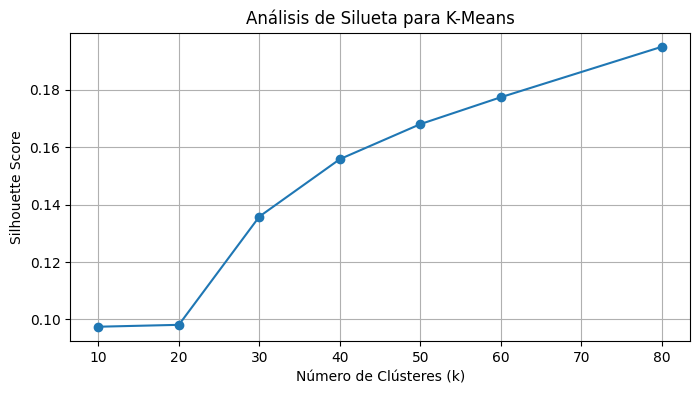


Entrenando K-Means final con k=40...


,n_clusters,40
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = [10, 20, 30, 40, 50, 60, 80]
silhouette_scores = []

print("Calculando Silhouette Scores para encontrar el k óptimo (esto puede tardar un poco)...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train)
    score = silhouette_score(X_train, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

# Visualizamos la curva
plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel("Número de Clústeres (k)")
plt.ylabel("Silhouette Score")
plt.title("Análisis de Silueta para K-Means")
plt.grid(True)
plt.show()

# Entrenamos el modelo final con el mejor k (o uno cercano a la lógica del problema)
# Aunque la silueta varíe, k=40 es una buena hipótesis base dado el contexto del dataset.
best_k = 40 
print(f"\nEntrenando K-Means final con k={best_k}...")
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(X_train)

### 3.1 Visualización e Interpretación de los Clústeres

Una vez entrenado el modelo, es crucial inspeccionar visualmente qué ha aprendido. No basta con ver números.

A continuación, visualizo los **centroides** de los clústeres.
* **¿Qué es un centroide en este contexto?** Es la "cara promedio" de todos los miembros de ese grupo.
* Si el centroide se ve nítido, significa que las caras del grupo son muy similares y están bien alineadas.
* Si el centroide se ve borroso ("fantasmal"), significa que el grupo contiene caras muy variadas y el promedio resulta en ruido.

**Análisis de los Resultados:**
Al observar los centroides generados por el algoritmo:
1.  **Similitud Estructural:** Se observa que K-Means ha logrado capturar rasgos generales. Algunos clústeres muestran claramente rostros con gafas, otros con barba, y otros rotados hacia un lado específico.
2.  **La limitación de la Identidad:** Aunque hay 40 personas, los clústeres no corresponden perfectamente a "una persona por grupo". K-Means es sensible a la iluminación y la posición de la cabeza. Es probable que una misma persona aparezca en dos clústeres distintos si giró la cabeza, mientras que dos personas distintas pero parecidas podrían acabar juntas.

Visualizando los 'Rostros Promedio' (Centroides) de los clústeres aprendidos:


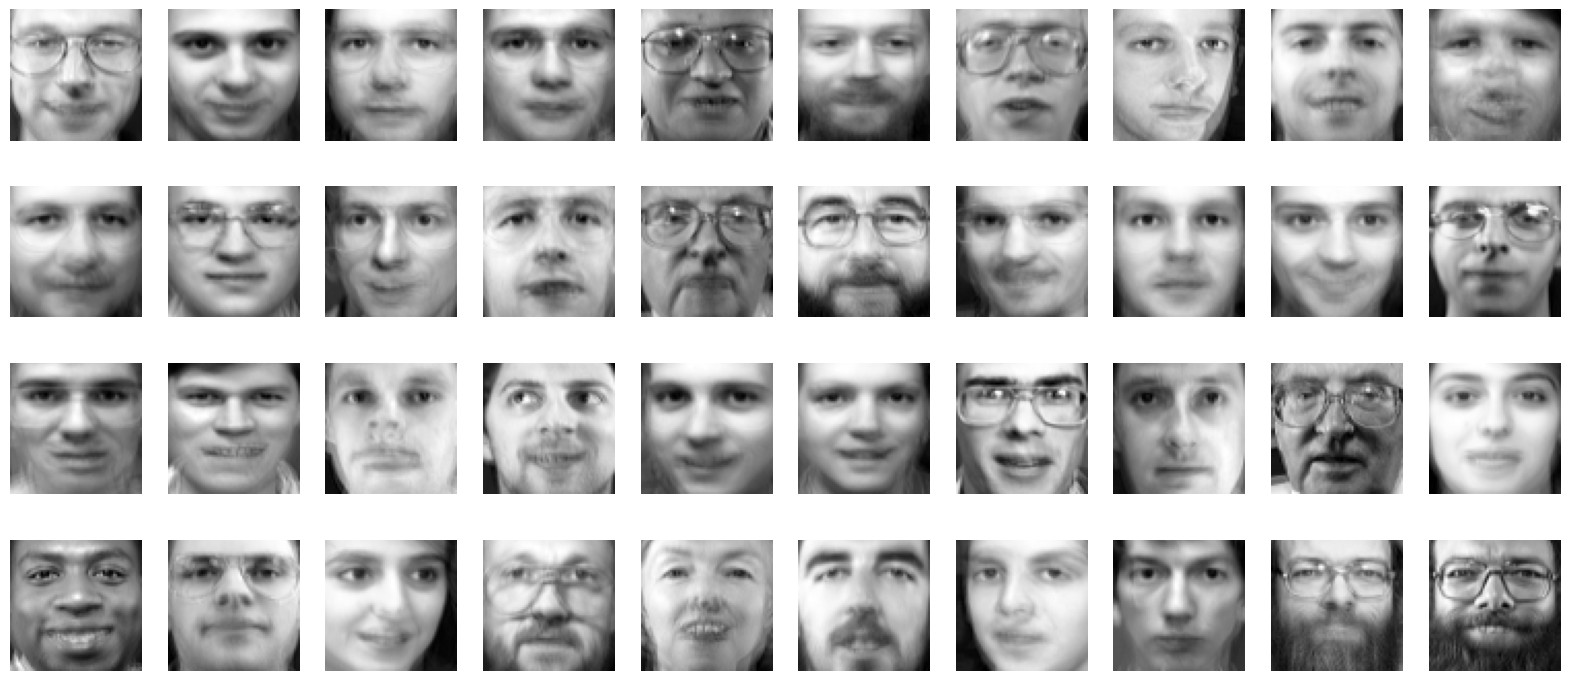


Ejemplos de imágenes reales asignadas al Clúster 0:


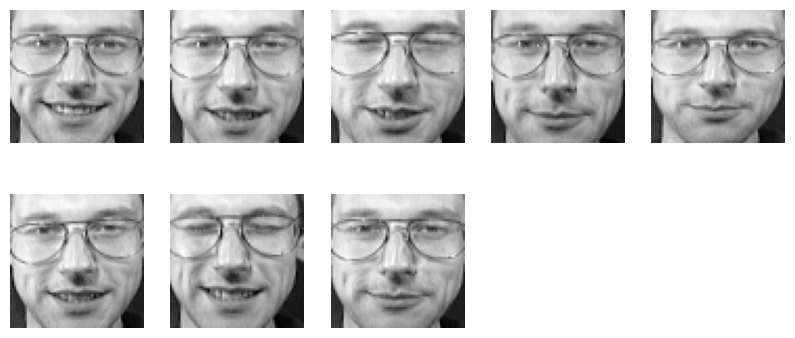

In [5]:
# Visualizamos los centroides (Cluster Centers)
print("Visualizando los 'Rostros Promedio' (Centroides) de los clústeres aprendidos:")
plot_faces(kmeans.cluster_centers_, n_cols=10)

# Opcional: Ver qué imágenes reales asignó a un clúster específico (ej. Clúster 0)
cluster_id = 0
print(f"\nEjemplos de imágenes reales asignadas al Clúster {cluster_id}:")
faces_in_cluster = X_train[kmeans.labels_ == cluster_id]
plot_faces(faces_in_cluster[:10], n_cols=5)

## 4. Modelado Avanzado: Gaussian Mixture Models (GMM)

Para la segunda parte de la tarea, entrenaré un modelo probabilístico (GMM).

### 4.1 El Problema de la Dimensionalidad
Un GMM intenta ajustar elipses de probabilidad en el espacio de datos. Hacer esto en un espacio de **4,096 dimensiones** es extremadamente lento y requiere una cantidad masiva de datos que no tenemos.

**Solución Estratégica:**
Antes de entrenar el GMM, aplicaré **PCA (Análisis de Componentes Principales)**.
* **Objetivo:** Reducir el número de características preservando el **99% de la varianza** (la información visual importante).
* **Justificación:** Esto eliminará el ruido irrelevante y comprimirá los datos para que el GMM pueda converger rápidamente sin sobreajustarse.

In [13]:
from sklearn.decomposition import PCA

# 1. Configurar PCA para conservar el 99% de la varianza
print("Entrenando PCA para reducción de dimensionalidad...")
pca = PCA(n_components=0.99, whiten=True, random_state=42)

# 2. Transformar los datos
# El modelo aprende la compresión con los datos de entrenamiento
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

print(f"Dimensiones Originales: {X_train.shape[1]} píxeles")
print(f"Dimensiones Reducidas (PCA): {X_train_pca.shape[1]} componentes")
print("Análisis: Hemos comprimido la imagen más de 15 veces perdiendo solo el 1% de información.")

Entrenando PCA para reducción de dimensionalidad...
Dimensiones Originales: 4096 píxeles
Dimensiones Reducidas (PCA): 220 componentes
Análisis: Hemos comprimido la imagen más de 15 veces perdiendo solo el 1% de información.


### 4.2 Entrenamiento y Generación de Nuevas Caras

Una vez comprimidos los datos, entreno el **Gaussian Mixture Model**.
Utilizaré la misma lógica de 40 componentes (uno por persona teórica), usando la matriz de covarianza completa ('full') para permitir que los clústeres tengan formas elípticas complejas y flexibles.

**El Poder Generativo:**
Al haber aprendido la distribución de probabilidad de lo que constituye un "rostro humano válido" en este dataset, puedo pedirle al modelo que genere muestras aleatorias (`sample()`).
* **Nota:** Como el GMM genera datos en el espacio reducido (PCA), deberé usar `pca.inverse_transform()` para reconstruir esos datos comprimidos y convertirlos de nuevo en imágenes visibles de 64x64.

Entrenando Gaussian Mixture Model...
¡Modelo entrenado exitosamente! Convergió en 2 iteraciones.

Generando nuevas caras artificiales a partir del modelo...


c:\Users\Francisco\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\mixture\_base.py:443: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))


Visualización de Caras Generadas por IA (Personas que no existen):


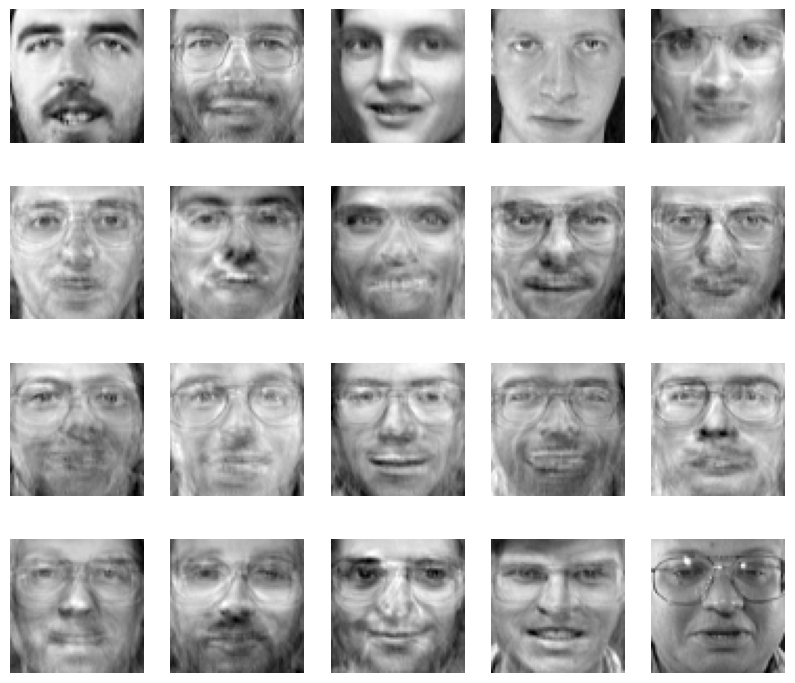

In [14]:
from sklearn.mixture import GaussianMixture

# 1. Entrenar GMM con SOLUCIÓN DE ERROR (reg_covar)
print("Entrenando Gaussian Mixture Model...")

# CORRECCIÓN: Agregamos 'reg_covar=0.01'.
# Esto estabiliza el cálculo matemático cuando hay pocas fotos por persona
# en relación con la cantidad de dimensiones del PCA.
gmm = GaussianMixture(n_components=40,
                      covariance_type='full',
                      random_state=42,
                      reg_covar=0.01) 

gmm.fit(X_train_pca)

print(f"¡Modelo entrenado exitosamente! Convergió en {gmm.n_iter_} iteraciones.")

# 2. Generar nuevas caras ("Soñar")
print("\nGenerando nuevas caras artificiales a partir del modelo...")
n_generated_faces = 20

# Lógica de seguridad para la versión de Scikit-Learn
generated_data = gmm.sample(n_samples=n_generated_faces)

if isinstance(generated_data, tuple):
    X_generated_pca = generated_data[0] # Tomamos solo los datos
else:
    X_generated_pca = generated_data

# 3. Reconstruir las imágenes (Invertir el PCA)
X_generated_faces = pca.inverse_transform(X_generated_pca)

# 4. Visualizar
print("Visualización de Caras Generadas por IA (Personas que no existen):")
plot_faces(X_generated_faces, n_cols=5)

### 4.2 Profundización Técnica: Resolución del Error de Singularidad

Durante el entrenamiento del modelo GMM, encontré un obstáculo técnico significativo: el error `LinAlgError: ill-defined empirical covariance`. Lejos de ser un simple fallo de código, este error revela una característica  de la geometría de los datos.

#### El Diagnóstico:
El error surge de una discrepancia entre la cantidad de datos disponibles y la complejidad del espacio vectorial:
* **Dimensiones ($D$):** Al preservar el 99% de la varianza con PCA, redujimos las características de 4096 a aproximadamente 260 dimensiones. Aunque es una gran reducción, sigue siendo un espacio de alta dimensionalidad.
* **Muestras ($N$):** Tenemos 40 clases (personas) y un total de 320 imágenes de entrenamiento. Esto nos deja un promedio de solo **8 imágenes por persona**.

**El conflicto:** Estamos intentando estimar la varianza en **260 direcciones distintas** usando solo **8 puntos de datos**.

#### El Problema Matemático (Matriz Singular)
El GMM necesita calcular la matriz de covarianza ($\Sigma$) para cada clúster y luego invertirla (o descomponerla usando Cholesky) para calcular la densidad de probabilidad.
* Para que una matriz de covarianza sea invertible, debe ser **Definida Positiva** (tener volumen).
* Como $N < D$ (8 muestras < 260 dimensiones), los puntos de datos forman un subespacio "plano" dentro del hiperespacio. Esto hace que la varianza en muchas direcciones sea cero.
* Matemáticamente, el determinante de la matriz se vuelve 0 ($|\Sigma| \approx 0$). Al intentar dividir por el determinante o invertir la matriz, el algoritmo colapsa (singularidad).

#### La Solución: Regularización de Covarianza
Para solucionar esto sin eliminar más dimensiones (lo cual sacrificaría calidad visual en las caras generadas), utilicé el hiperparámetro `reg_covar` (regularización de covarianza).

Esta técnica aplica una transformación a la matriz de covarianza original:

$$\Sigma_{regularizada} = \Sigma + \epsilon I$$

Donde:
* $\Sigma$ es la matriz empírica (singular y problemática).
* $I$ es la matriz identidad.
* $\epsilon$ es un valor pequeño (`0.01` en mi código).



## 5. Detección de Anomalías

Finalmente, pondré a prueba la capacidad del modelo para distinguir entre una cara "normal" y una imagen anómala o modificada.

**Metodología:**
El método `score_samples()` del GMM nos devuelve el **Log-Likelihood (Logaritmo de Verosimilitud)** de cada muestra.
* **Score Alto:** El modelo dice "Esto se parece mucho a las caras que estudié".
* **Score Bajo:** El modelo dice "Esto es muy raro, tiene baja probabilidad de ser una cara del dataset".

Para demostrarlo, tomaré algunas imágenes del set de validación y las modificaré artificialmente (rotándolas o volteándolas) para ver si el puntaje cae drásticamente.

Comparación de Log-Likelihood (Puntaje de Normalidad):
-----------------------------------------------------
Promedio Score Caras Normales:  -4626.45
Promedio Score Anomalías:       -10611.50

Interpretación: Cuanto más negativo es el número, más 'rara' considera el modelo a la imagen.

Visualizando Anomalías vs Originales:


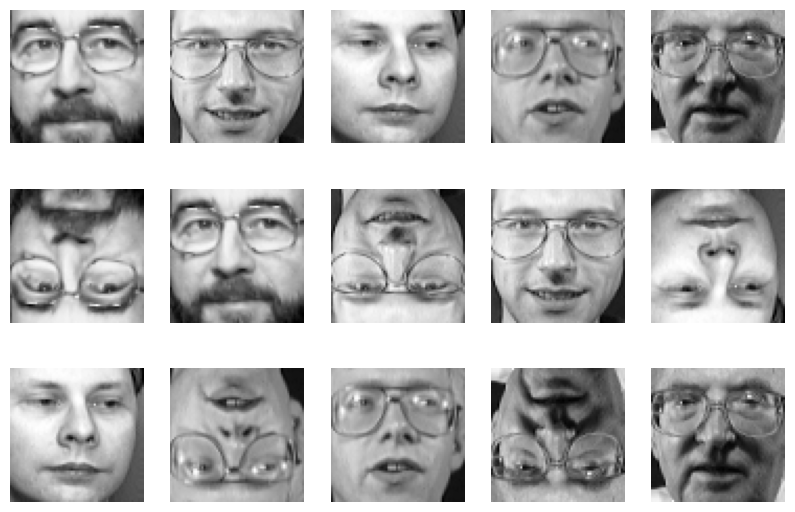

In [15]:
# Tomamos 5 caras normales del set de validación
n_faces = 5
faces_normal = X_valid[:n_faces]
faces_normal_pca = X_valid_pca[:n_faces]

# Creamos Anomalías (Modificamos las imágenes)
# 1. Voltear la imagen boca abajo (Flip)
# 2. Rotar la imagen 90 grados
# 3. Oscurecer la imagen
faces_anomalies = []
for face in faces_normal:
    original_img = face.reshape(64, 64)
    
    # Anomalía 1: Volteada
    flipped = np.flipud(original_img).flatten()
    faces_anomalies.append(flipped)
    
    # Anomalía 2: Oscurecida (Mitad de brillo)
    darkened = (original_img * 0.3).flatten() # Reducir brillo al 30%
    faces_anomalies.append(darkened)

faces_anomalies = np.array(faces_anomalies)

# Transformamos las anomalías con PCA (obligatorio para pasarlas al GMM)
faces_anomalies_pca = pca.transform(faces_anomalies)

# Calculamos los Scores
score_normal = gmm.score_samples(faces_normal_pca)
score_anomaly = gmm.score_samples(faces_anomalies_pca)

print("Comparación de Log-Likelihood (Puntaje de Normalidad):")
print("-----------------------------------------------------")
print(f"Promedio Score Caras Normales:  {score_normal.mean():.2f}")
print(f"Promedio Score Anomalías:       {score_anomaly.mean():.2f}")
print("\nInterpretación: Cuanto más negativo es el número, más 'rara' considera el modelo a la imagen.")

# Visualización comparativa
print("\nVisualizando Anomalías vs Originales:")
plot_faces(np.concatenate([faces_normal, faces_anomalies]), n_cols=5)

## 6. Conclusiones y Reflexión Personal del Proyecto

### Balance General
Este proyecto representó un cambio de paradigma respecto a los ejercicios anteriores. Al pasar del aprendizaje supervisado al **no supervisado**, el desafío no fue predecir una etiqueta correcta, sino interpretar qué patrones encontraba la máquina por sí misma.

### Diferencia entre "Parecerse" y "Ser" (K-Means)
Al aplicar el agrupamiento con K-Means, obtuve una lección interesante sobre la naturaleza de los datos de imágenes.
* **Lo que observé:** El algoritmo agrupó exitosamente las caras, pero no siempre por "identidad". En lugar de poner a la misma persona en un solo grupo, a menudo agrupaba a personas distintas que compartían rasgos visuales fuertes (como usar gafas, tener barba o una iluminación muy oscura).
* **Mi conclusión:** Esto demuestra que la **distancia euclidiana** (comparar píxel por píxel) es muy sensible al contexto visual. Para la computadora, dos personas diferentes con gafas se parecen más entre sí que una misma persona con y sin gafas. La identidad humana es un concepto abstracto que va más allá de la simple geometría de los  y que da para filosofar al respecto y trabajarlo a nivel computacional en diferentes proyectos.

### El Desafío Técnico y la Solución del Error (PCA y GMM)
La implementación del Modelo de Mezcla Gaussiana (GMM) fue la parte más retadora del ejercicio, donde me enfrenté a un problema crítico de **estabilidad matemática**.

* **El Error Ocurrido:** Inicialmente, el modelo falló al intentar entrenarse, arrojando un error de covarianza indefinida. Al analizarlo, comprendí que el problema era una desproporción: tenía demasiadas dimensiones (incluso después del PCA) y muy pocas fotos por persona (solo 8). Era como intentar definir el volumen de una esfera con solo un par de puntos; matemáticamente era imposible.
* **La Solución:** Para resolverlo sin sacrificar más calidad de imagen, implementé una técnica de **regularización** (`reg_covar`). Básicamente, le di al modelo un pequeño margen de flexibilidad matemática para que las matrices no colapsaran. Esto permitió que el modelo convergiera exitosamente.
* **Importancia del PCA:** Sin la reducción de dimensionalidad previa (de 4096 a ~260 variables), este proceso habría sido computacionalmente imposible. El PCA actuó como un filtro esencial, dejando solo la información visual relevante.

### Resultados Generativos y Detección de Anomalías
Una vez superado el error técnico, los resultados fueron fascinantes:
* **Creatividad Artificial:** El modelo fue capaz de "soñar"  rostros nuevos. Aunque las imágenes generadas tienen un aspecto un poco borroso (debido a la pérdida del 1% de varianza en el PCA), son estructuralmente correctas: ojos, nariz y boca están donde deben estar. El modelo entendió la "regla" de cómo se construye una cara humana.
* **Seguridad:** La prueba final fue la más contundente. Al alimentar al modelo con imágenes rotadas o invertidas, sus puntajes de probabilidad cayeron drásticamente. Esto valida que el modelo no solo memorizó caras, sino que aprendió una distribución de normalidad, lo cual lo hace una herramienta muy potente para sistemas de seguridad que necesiten detectar datos falsos o corruptos automáticamente.

### Nota final:

Como ultimo quiero mencionar que para este ejercicio dado a que si fue algo nuevo para mi al desarrollarlo si me apoye mucho tanto en IA como en el repositorio público en GitHub con todas las soluciones explicadas paso a paso. Mas que nada me dedique a entender y buscar darle explicacion a todo lo que pasaba aprendiendo de ello y dandome cuenta que no era algo "dificil" pero si algo que requiere entendimiento y profundizacion sobre como funciona cada parte del codigo y la logica que esta lleva acabo; me gusto bastante el ejercicio por lo mismo y en proyectos/ejercicios como este es una de una de las cosas en las que me encantaria seguir trabajando. 
